# 5. Model Development

This notebook develops and compares four models for predicting 30-day hospital readmission:

1. **Logistic Regression** — interpretable baseline.
2. **Random Forest** — captures non-linear relationships and feature interactions.
3. **Gradient Boosting** — improves predictions through sequential tree learning.
4. **Multilayer Perceptron (MLP)** — neural-network benchmark for more complex patterns.

The models provide a progression from a statistical baseline to more flexible machine-learning approaches.

Because 30-day readmission is an imbalanced outcome, **PR-AUC is the primary model-selection metric**. **Recall** is the key operational metric, reflecting the proportion of actual readmissions successfully identified.

ROC-AUC, precision, F1-score, and accuracy are reported as supporting metrics.

## 5.1 Import Libraries

Libraries are imported for data preparation, patient-aware splitting, preprocessing, model development, and performance evaluation.

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score
)

## 5.2 Load the Modeling Dataset

The prepared modeling dataset is loaded for model development. The patient identifier is retained temporarily to support patient-aware data splitting but will not be used as a predictor.

In [3]:
df_model = pd.read_csv("../data/processed/modeling_data.csv")

print("Dataset shape:", df_model.shape)
df_model.head()

Dataset shape: (101763, 35)


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,...,rosiglitazone,acarbose,insulin,glyburide-metformin,change,diabetesMed,readmitted_30,diag_1_group,diag_2_group,diag_3_group
0,8222157,Caucasian,Female,[0-10),6,25,1,1,Other Specialty,41,...,No,No,No,No,No,No,0,Diabetes,Unknown,Unknown
1,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,...,No,No,Up,No,Ch,Yes,0,Other,Diabetes,Other
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,...,No,No,No,No,No,Yes,0,Other,Diabetes,Other
3,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,...,No,No,Up,No,Ch,Yes,0,Other,Diabetes,Circulatory
4,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,...,No,No,Steady,No,Ch,Yes,0,Neoplasms,Neoplasms,Diabetes


### 5.2.1 Restore Administrative Categorical Features

The administrative ID variables represent categories rather than numerical quantities. Since CSV files may reload these variables as numeric values, they are converted back to categorical format before modeling.

In [4]:
categorical_ids = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

df_model[categorical_ids] = df_model[categorical_ids].astype(str)

In [5]:
df_model[categorical_ids].dtypes

admission_type_id           str
discharge_disposition_id    str
admission_source_id         str
dtype: object

## 5.3 Patient-Aware Train-Test Split
Because patients may have multiple hospital encounters, the data is split by `patient_nbr` rather than by individual encounters. This prevents encounters from the same patient appearing in both the training and test sets.

Patient groups are retained for later cross-validation, while the patient identifier is removed before model training.

In [6]:
X = df_model.drop(columns="readmitted_30")
y = df_model["readmitted_30"]
groups = df_model["patient_nbr"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

groups_train = X_train["patient_nbr"].copy()
groups_test = X_test["patient_nbr"].copy()

### 5.3.1 Verify Patient Separation

The split is checked to confirm that no patient appears in both datasets.

In [7]:
print("Patient overlap:", len(set(groups_train) & set(groups_test)))

Patient overlap: 0


### 5.3.2 Finalize the Modeling Sets

The patient identifier is removed from the predictors after the groups have been preserved. The final partitions are then checked for size and readmission prevalence.

In [8]:
X_train.drop(columns="patient_nbr", inplace=True)
X_test.drop(columns="patient_nbr", inplace=True)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print(f"Train readmission rate: {y_train.mean():.2%}")
print(f"Test readmission rate: {y_test.mean():.2%}")

Train shape: (81670, 33)
Test shape: (20093, 33)
Train readmission rate: 11.22%
Test readmission rate: 10.92%


## 5.4 Modeling Preprocessor

The preprocessing strategy established in Notebook 04 is recreated for use within the model pipelines.

In [11]:
numerical_cols = X_train.select_dtypes(include="number").columns.tolist()
categorical_cols = X_train.select_dtypes(exclude="number").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

print(f"Numerical features: {len(numerical_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numerical features: 8
Categorical features: 25


## 5.5 Model Validation Strategy

Candidate models are compared using patient-aware cross-validation on the training set.`StratifiedGroupKFold` keeps encounters from the same patient within a single fold while also maintaining a similar readmission distribution across folds.

**PR-AUC** is the primary model-selection metric, with **recall** treated as the key operational metric. ROC-AUC, precision, F1-score, and accuracy are included as supporting measures.

The held-out test set is not used during model comparison and is reserved for final evaluation.

In [14]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "accuracy": "accuracy"
}

Five-fold patient-aware cross-validation will be applied consistently to each candidate model. Mean validation performance will then be compared across models, with PR-AUC serving as the primary criterion for model selection.

## 5.6 Logistic Regression: Baseline Model

Logistic Regression is used as the baseline model because it provides a simple and interpretable benchmark for binary classification.

The model is combined with the preprocessing pipeline and evaluated using the patient-aware cross-validation strategy defined above.

### 5.6.1 Logistic Regression Pipeline

The preprocessing steps and Logistic Regression classifier are combined into a single pipeline. This ensures that preprocessing is performed within each training fold during cross-validation, helping prevent data leakage.

In [16]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 5.6.2 Cross-Validation Performance

The Logistic Regression model is evaluated using five-fold patient-aware cross-validation.

PR-AUC is used as the primary model-selection metric, while recall measures the model's ability to identify patients who experience a 30-day readmission. ROC-AUC, precision, F1-score, and accuracy provide additional performance context.

In [18]:
logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

logistic_results = pd.Series({
    metric: logistic_cv[f"test_{metric}"].mean()
    for metric in scoring
})

model_results = {
    "Logistic Regression": logistic_results
}

logistic_results.round(3)

pr_auc       0.215
roc_auc      0.666
recall       0.020
precision    0.504
f1           0.039
accuracy     0.888
dtype: float64


Logistic Regression achieved a PR-AUC of **0.215** and ROC-AUC of **0.666**, indicating modest ability to distinguish patients at higher risk of 30-day readmission. However, recall was only **0.020**, meaning that at the default classification threshold the model identified very few actual readmissions.

The high accuracy of **0.888** largely reflects the class imbalance and should therefore not be interpreted as strong predictive performance. Precision was relatively high at **0.504**, but this applies to the small number of encounters classified as readmissions.

These results establish a useful baseline for comparison with models that can capture more complex and non-linear relationships.

## 5.7 Random Forest

Random Forest is evaluated as a non-linear alternative to Logistic Regression. By combining multiple decision trees, the model can capture more complex relationships and interactions among patient, utilization, and clinical characteristics.

### 5.7.1 Random Forest Pipeline

The Random Forest classifier is combined with the existing preprocessing pipeline to maintain a consistent modeling workflow.

In [19]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 5.7.2 Cross-Validation Performance

The Random Forest pipeline is evaluated using the same five-fold patient-aware cross-validation strategy. Mean validation performance is calculated and stored for comparison with the baseline model.

In [20]:
random_forest_cv = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

random_forest_results = pd.Series({
    metric: random_forest_cv[f"test_{metric}"].mean()
    for metric in scoring
})

model_results["Random Forest"] = random_forest_results

random_forest_results.round(3)

pr_auc       0.217
roc_auc      0.657
recall       0.002
precision    0.381
f1           0.004
accuracy     0.888
dtype: float64

 
Random Forest achieved a PR-AUC of **0.217** and ROC-AUC of **0.657**, providing little improvement in ranking performance over the Logistic Regression baseline.

At the default classification threshold, recall was only **0.002**, indicating that the model classified almost all encounters as non-readmissions. The high accuracy of **0.888** therefore mainly reflects the predominance of the negative class rather than effective identification of 30-day readmissions.

Although Random Forest can capture non-linear relationships and feature interactions, these results show no meaningful improvement over the simpler Logistic Regression model at this stage.

## 5.8 Gradient Boosting

Gradient Boosting is evaluated as a more flexible tree-based model that learns sequentially from prediction errors. This approach can capture non-linear relationships and interactions that may not be represented by the Logistic Regression baseline.

A dense preprocessing pipeline is used because `HistGradientBoostingClassifier` requires dense input.

### 5.8.1 Gradient Boosting Pipeline

The same numerical scaling and categorical encoding strategy is retained, with one-hot encoding configured to return a dense feature matrix compatible with the Gradient Boosting classifier.

In [21]:
dense_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), categorical_cols)
])

gradient_boosting_pipeline = Pipeline([
    ("preprocessor", dense_preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=100,
        random_state=42
    ))
])

gradient_boosting_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 5.8.2 Cross-Validation Performance

The Gradient Boosting pipeline is evaluated using the same five-fold patient-aware cross-validation strategy. Mean validation performance is calculated and stored for comparison with the previous models.

In [22]:
gradient_boosting_cv = cross_validate(
    gradient_boosting_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

gradient_boosting_results = pd.Series({
    metric: gradient_boosting_cv[f"test_{metric}"].mean()
    for metric in scoring
})

model_results["Gradient Boosting"] = gradient_boosting_results

gradient_boosting_results.round(3)

pr_auc       0.227
roc_auc      0.675
recall       0.011
precision    0.587
f1           0.021
accuracy     0.888
dtype: float64


Gradient Boosting achieved the strongest ranking performance so far, with a PR-AUC of **0.227** and ROC-AUC of **0.675**, outperforming both Logistic Regression and Random Forest.

However, recall remained very low at **0.011**, showing that the default classification threshold identifies only a small proportion of actual 30-day readmissions. Precision was comparatively high at **0.587**, indicating that the relatively few encounters classified as readmissions were often correctly identified.

The results suggest that Gradient Boosting provides better risk ranking, but threshold optimization may be necessary to improve its usefulness for identifying patients at risk of readmission.

## 5.9 Multilayer Perceptron (MLP)

A Multilayer Perceptron is evaluated as the neural-network benchmark. Unlike the previous models, the MLP can learn complex non-linear relationships through interconnected hidden layers. The model uses the existing preprocessing pipeline, with standardized numerical features and one-hot encoded categorical features.

### 5.9.1 MLP Pipeline

A compact neural network with two hidden layers is used for the initial model comparison. Early stopping is enabled to reduce unnecessary training once validation performance stops improving.

In [23]:
mlp_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=200,
        early_stopping=True,
        random_state=42
    ))
])

mlp_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 5.9.2 Cross-Validation Performance

The MLP pipeline is evaluated using the same patient-aware cross-validation strategy. Mean validation performance is calculated and stored for comparison with the other candidate models.

In [24]:
mlp_cv = cross_validate(
    mlp_pipeline,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

mlp_results = pd.Series({
    metric: mlp_cv[f"test_{metric}"].mean()
    for metric in scoring
})

model_results["MLP"] = mlp_results

mlp_results.round(3)

pr_auc       0.215
roc_auc      0.666
recall       0.017
precision    0.512
f1           0.033
accuracy     0.888
dtype: float64

 The MLP achieved a PR-AUC of **0.215** and ROC-AUC of **0.666**, closely matching the Logistic Regression baseline.

Recall remained very low at **0.017**, while precision was **0.512**, indicating that the model remained conservative when predicting 30-day readmission. The additional complexity of the neural network therefore did not translate into improved predictive performance.

Among the models evaluated so far, Gradient Boosting remains the strongest based on the primary PR-AUC metric.

## 5.10 Model Comparison

The cross-validation results from all four candidate models are compared to identify the strongest approach for predicting 30-day readmission.

PR-AUC remains the primary model-selection metric because it is well suited to the imbalanced outcome. Recall is considered alongside PR-AUC because identifying patients who are actually readmitted is particularly important in this application.

### 5.10.1 Cross-Validation Results

Mean cross-validation performance is summarized across all evaluation metrics and ranked by PR-AUC.

In [25]:
comparison_df = pd.DataFrame(model_results).T

comparison_df = comparison_df[
    ["pr_auc", "roc_auc", "recall", "precision", "f1", "accuracy"]
].sort_values("pr_auc", ascending=False)

comparison_df.round(3)

,pr_auc,roc_auc,recall,precision,f1,accuracy
Gradient Boosting,0.227,0.675,0.011,0.587,0.021,0.888
Random Forest,0.217,0.657,0.002,0.381,0.004,0.888
MLP,0.215,0.666,0.017,0.512,0.033,0.888
Logistic Regression,0.215,0.666,0.020,0.504,0.039,0.888


### 5.10.2 Ranking Performance

PR-AUC and ROC-AUC are visualized to compare each model's ability to rank patients according to readmission risk.

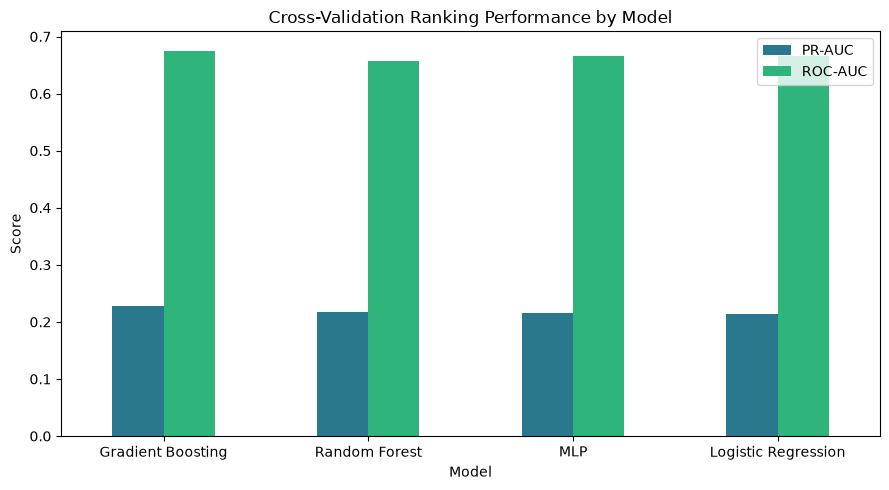

In [27]:
import matplotlib.pyplot as plt

viridis = plt.cm.viridis

colors = [
    viridis(0.40),  # blue-teal
    viridis(0.65)   # green
]

comparison_df[["pr_auc", "roc_auc"]].plot(
    kind="bar",
    figsize=(9, 5),
    color=colors
)

plt.title("Cross-Validation Ranking Performance by Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(["PR-AUC", "ROC-AUC"])
plt.tight_layout()
plt.show()


Gradient Boosting achieved the strongest ranking performance, with the highest **PR-AUC (0.227)** and **ROC-AUC (0.675)** among the four candidate models.

Random Forest produced a slightly higher PR-AUC than Logistic Regression but performed worse on ROC-AUC and default-threshold recall. The MLP provided no meaningful improvement over Logistic Regression despite its greater model complexity.

Recall remained very low across all four models at the default classification threshold, indicating that model selection alone does not resolve the challenge of identifying readmissions. Threshold selection and the trade-off between recall and precision therefore require further evaluation.

Based on the primary PR-AUC criterion, **Gradient Boosting is selected as the leading candidate for further evaluation.**

## 5.11 Model Selection and Summary

Four candidate models were evaluated using patient-aware cross-validation: Logistic Regression, Random Forest, Gradient Boosting, and a Multilayer Perceptron.

Gradient Boosting achieved the highest **PR-AUC (0.227)** and **ROC-AUC (0.675)**, making it the strongest candidate based on the predefined model-selection criterion. Logistic Regression remained a competitive and considerably simpler baseline, while Random Forest and MLP did not provide meaningful improvements.

Despite differences in ranking performance, recall remained very low across all models at the default classification threshold. This suggests that the models can identify relative differences in readmission risk, but the default decision threshold is not appropriate for identifying a sufficient proportion of actual readmissions.

Based on cross-validation performance, **Gradient Boosting is selected for further evaluation**. The held-out test set remains untouched and will be used in the next notebook for final model assessment, threshold analysis, and evaluation of the trade-off between recall and precision.

In [28]:
comparison_df.to_csv(
    "../data/processed/model_comparison_results.csv"
)

print("Model comparison results saved.")

Model comparison results saved.
